### The Transformer:

The Transformer is the architecture that enabled a new industrial revolution in the AI field, enabling the creation of powerfoul (and expensive) chatbots that can handle, a wide range of text based task and not only, has been discovered that creating very big transformers trained on a lot of datas allows the model to learn new skills where they where not trained with a fenomenon that has been called emergence.

The transformer is very data hungry and computational expensive, and their prestations rely strongly on the amount of data they recieve and their quality.
Nowdays deploying a LLM is very expensive, so only bigh tech companies have the capabilities to create a big model in terms of datas and computational power.

### The Original transformer-(Encoder, Decoder) architecture (From 2017):

Is important to notice that this is not the architecture we use nowadays. Modern LLMs use a **decoder-only architecture**, which is optimized for autoregressive language modeling. 

By contrast, modern LLMs (such as GPT, LLaMA, Mistral) remove the encoder entirely and rely on stacked **decoder blocks** with masked self-attention. Each block predicts the next token given the previous ones, making the model highly scalable and efficient for generative tasks like dialogue, reasoning, and code completion.

This architectural simplification — moving from encoder–decoder to decoder-only — is what enabled today’s large language models to scale to billions of parameters and excel at open-ended text generation.

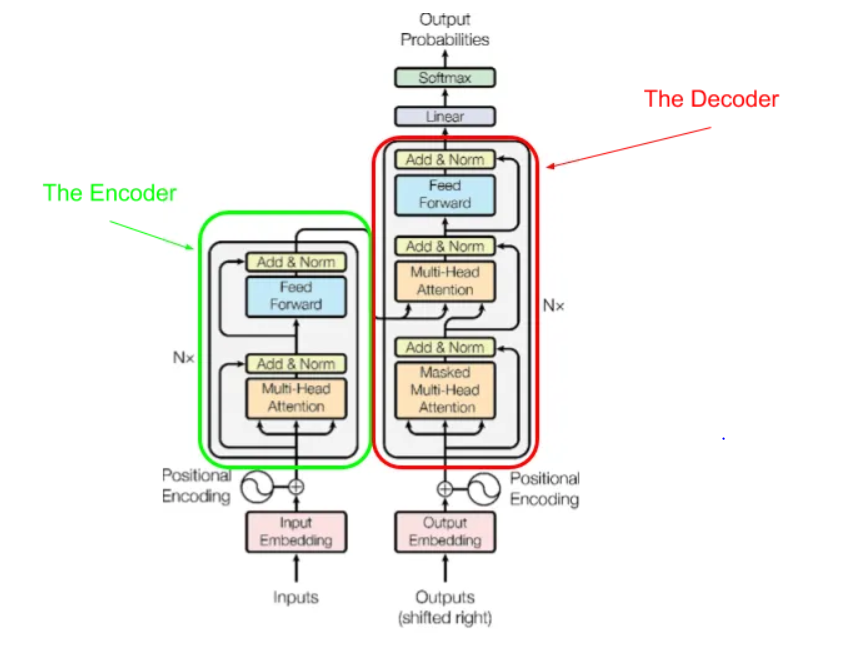

### Encoder And Decoder:
We may notice from the image taken from the legendary paper *"Attention Is All You Need"* two blocks:

- **The Encoder**:  
  The encoder is tasked with the understanding of the received data.  
  It has a **bidirectional attention**, meaning it can process the whole sequence at once and "find"  
  the best contextual representation for that sequence.

- **The Decoder**:  
  The decoder is tasked with generating the output sequence step by step.  
  It uses **masked self-attention** so that each position can only attend to previous tokens, preventing the model from "cheating" by looking ahead.  
  Additionally, the decoder includes **encoder–decoder attention**, which allows it to attend to the encoder’s output representations.  
  This mechanism ensures that the generated tokens are informed both by the already produced output and by the full context of the input sequence.


Modern large language models (LLMs) do not use this encoder–decoder setup. Instead, they adopt a **decoder-only architecture**, stacking multiple decoder blocks with masked self-attention. This design is optimized for autoregressive language modeling, where the model predicts the next token given all previous ones.  
This simplification makes scaling easier and is the foundation of today’s generative models like GPT, LLaMA, and Mistral.

---

Now we will see how a modern era transformer(decoder only) is built, analizing each step of it's creation to obtain simplified and humble gpt model.

**1. Tokenization (Sub-word Tokenization)**

Raw text is segmented into tokens using **Byte Pair Encoding (BPE)**.  
- Splits rare/unknown words into sub-word units down to characters.  
- Removes need for `<|unk|>` token.  
- Efficient vocabulary (~50k tokens).  

**Output**: Sequence of integer IDs.

In [10]:
# Example: BPE tokenization
from transformers import GPT2Tokenizer ### Library from huggingface

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
text = "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua."
tokens_txt = tokenizer.tokenize(text)
tokens_indx = tokenizer.convert_tokens_to_ids(tokens_txt)

print("Tokenized(Splitted) Words : ", tokens_txt)
print("Tokens:", tokens_indx)

### G is used to represent spaces

Tokenized(Splitted) Words :  ['L', 'orem', 'Ġ', 'ips', 'um', 'Ġd', 'olor', 'Ġsit', 'Ġam', 'et', ',', 'Ġcon', 'sect', 'et', 'ur', 'Ġadip', 'is', 'cing', 'Ġel', 'it', ',', 'Ġsed', 'Ġdo', 'Ġe', 'ius', 'mod', 'Ġtempor', 'Ġinc', 'id', 'id', 'unt', 'Ġut', 'Ġlab', 'ore', 'Ġet', 'Ġd', 'ol', 'ore', 'Ġmag', 'na', 'Ġal', 'iqu', 'a', '.']
Tokens: [43, 29625, 220, 2419, 388, 288, 45621, 1650, 716, 316, 11, 369, 8831, 316, 333, 31659, 271, 2259, 1288, 270, 11, 10081, 466, 304, 3754, 4666, 10042, 753, 312, 312, 2797, 3384, 2248, 382, 2123, 288, 349, 382, 2153, 2616, 435, 1557, 64, 13]


## 2. Embedding Layer (Static Semantic Representation)

Each token ID → dense vector of floats.  
- Initialized randomly.  
- Updated during training to capture intrinsic meaning.  
- Dimension depends on architecture (e.g., 768 → 12k).  

In [11]:
import torch
import torch.nn as nn

embedding_dim = 2
vocab_size = tokenizer.vocab_size

embedding_layer = nn.Embedding(vocab_size, embedding_dim)
embedded = embedding_layer(torch.tensor(tokens_indx))

for index in range(10):
    print("Token txt = |", tokens_txt[index], "|Token embedding = ", embedded[index])

Token txt = | L |Token embedding =  tensor([ 2.1982, -0.1541], grad_fn=<SelectBackward0>)
Token txt = | orem |Token embedding =  tensor([-1.0505,  0.2899], grad_fn=<SelectBackward0>)
Token txt = | Ġ |Token embedding =  tensor([-1.3036,  0.7663], grad_fn=<SelectBackward0>)
Token txt = | ips |Token embedding =  tensor([1.7872, 1.1712], grad_fn=<SelectBackward0>)
Token txt = | um |Token embedding =  tensor([-0.1568,  2.8603], grad_fn=<SelectBackward0>)
Token txt = | Ġd |Token embedding =  tensor([-0.8160,  0.8004], grad_fn=<SelectBackward0>)
Token txt = | olor |Token embedding =  tensor([-0.6073,  1.0244], grad_fn=<SelectBackward0>)
Token txt = | Ġsit |Token embedding =  tensor([ 0.7607, -0.3319], grad_fn=<SelectBackward0>)
Token txt = | Ġam |Token embedding =  tensor([0.0747, 0.4834], grad_fn=<SelectBackward0>)
Token txt = | et |Token embedding =  tensor([0.6904, 1.3428], grad_fn=<SelectBackward0>)


### 3. Data Loader 

We need A data loader for taking a certain part of the text and feed it to the model, usually we give the model n words and it will guess the next one.

In [12]:
def dataloader(text_tokenized):
    window = 3
    x = []
    y = []
    for index in range(len(text_tokenized)- window):
        x.append(list(text_tokenized[index:index+window]))
        y.append(list(text_tokenized[index+1:index+window+1]))

    return x, y 

x, y = dataloader(tokens_indx)
print("X dataset\n", x)
print("X dataset\n", y)

X dataset
 [[43, 29625, 220], [29625, 220, 2419], [220, 2419, 388], [2419, 388, 288], [388, 288, 45621], [288, 45621, 1650], [45621, 1650, 716], [1650, 716, 316], [716, 316, 11], [316, 11, 369], [11, 369, 8831], [369, 8831, 316], [8831, 316, 333], [316, 333, 31659], [333, 31659, 271], [31659, 271, 2259], [271, 2259, 1288], [2259, 1288, 270], [1288, 270, 11], [270, 11, 10081], [11, 10081, 466], [10081, 466, 304], [466, 304, 3754], [304, 3754, 4666], [3754, 4666, 10042], [4666, 10042, 753], [10042, 753, 312], [753, 312, 312], [312, 312, 2797], [312, 2797, 3384], [2797, 3384, 2248], [3384, 2248, 382], [2248, 382, 2123], [382, 2123, 288], [2123, 288, 349], [288, 349, 382], [349, 382, 2153], [382, 2153, 2616], [2153, 2616, 435], [2616, 435, 1557], [435, 1557, 64]]
X dataset
 [[29625, 220, 2419], [220, 2419, 388], [2419, 388, 288], [388, 288, 45621], [288, 45621, 1650], [45621, 1650, 716], [1650, 716, 316], [716, 316, 11], [316, 11, 369], [11, 369, 8831], [369, 8831, 316], [8831, 316, 333], 

## 4. Positional Encoding (Injecting Order)

Transformers process tokens in parallel → no inherent sequence.  
Add positional encoding (fixed or learned) to embeddings.  
Now vector encodes both **what** (semantics) and **where** (position).


In [13]:
import math

def positional_encoding(seq_len, dim):
    pe = torch.zeros(seq_len, dim)
    for pos in range(seq_len):
        for i in range(0, dim, 2):
            pe[pos, i] = math.sin(pos / (10000 ** ((2*i)/dim)))
            pe[pos, i+1] = math.cos(pos / (10000 ** ((2*i)/dim)))
    return pe

pos_enc = positional_encoding(len(tokens_indx), embedding_dim)
embedded_with_pos = embedded + pos_enc
print(embedded_with_pos[:10])

tensor([[ 2.1982,  0.8459],
        [-0.2090,  0.8302],
        [-0.3944,  0.3502],
        [ 1.9283,  0.1812],
        [-0.9136,  2.2066],
        [-1.7750,  1.0841],
        [-0.8867,  1.9846],
        [ 1.4177,  0.4220],
        [ 1.0641,  0.3379],
        [ 1.1025,  0.4317]], grad_fn=<SliceBackward0>)


### 5. Linear Projections (Preparing for Attention)

Input vector `x` → multiplied by trainable matrices:  
- **Q** (Query): request for info  
- **K** (Key): label/index  
- **V** (Value): actual content  


In [14]:
W_Q = nn.Linear(embedding_dim, embedding_dim)
W_K = nn.Linear(embedding_dim, embedding_dim)
W_V = nn.Linear(embedding_dim, embedding_dim)

Q = W_Q(embedded_with_pos)
K = W_K(embedded_with_pos)
V = W_V(embedded_with_pos)

## 6. Self-Attention (Contextualization)

- Dot product of Q and K → attention scores.  
- Softmax → weights.  
- Weighted sum of V → context-aware representation.  


In [15]:
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(embedding_dim)
weights = torch.softmax(scores, dim=-1)
attention_output = torch.matmul(weights, V)

## 6. Stack of Transformer Blocks (Deep Learning)

Attention + Feed Forward Network repeated **N times** (e.g., 96 layers).  
Each layer refines understanding:  
- Lower → syntax  
- Higher → abstract semantics  

In [16]:
# Simplified transformer block
class TransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads=1)
        self.ff = nn.Sequential(
            nn.Linear(dim, 4*dim),
            nn.ReLU(),
            nn.Linear(4*dim, dim)
        )
    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        return self.ff(attn_out)

block = TransformerBlock(embedding_dim)
x = embedded_with_pos.unsqueeze(1)  # add batch dimension
out = block(x)

## 7. Final Head and Prediction (Next Token Prediction)

- Last block output → linear layer (Unembedding).  
- **Logits**: project to vocab size.  
- **Softmax**: convert to probabilities.  
- **Sampling**: choose next token (Greedy, Top-k, etc.).  


In [17]:
unembedding = nn.Linear(embedding_dim, vocab_size)
logits = unembedding(out.squeeze(1))
probs = torch.softmax(logits, dim=-1)

next_token_id = torch.argmax(probs[-1])  # greedy
tokenizer.decode([next_token_id.item()])

'Unique'